In [9]:
import numpy as np
import pandas as pd
import os
import glob
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input
from tensorflow.keras.models import Model

In [17]:
# Load annotations
annotations = pd.read_csv('data/metadata/annotations.csv')

# Function to load and resize spectrograms
def load_and_resize_spectrograms(directory, target_shape):
    spectrograms = []
    song_ids = []
    for filepath in glob.glob(os.path.join(directory, '*.npy')):
        spectrogram = np.load(filepath)
        # Resize the spectrogram to the target shape
        resized_spectrogram = cv2.resize(spectrogram, target_shape, interpolation=cv2.INTER_AREA)
        spectrograms.append(resized_spectrogram)
        song_id = int(os.path.splitext(os.path.basename(filepath))[0])
        song_ids.append(song_id)
    return np.array(spectrograms), np.array(song_ids)

# Target shape for resizing
target_shape = (128, 128)

# Load and resize spectrograms
spectrograms, song_ids = load_and_resize_spectrograms('data/spectrogram/', target_shape)

# Normalize spectrograms
scaler = StandardScaler()
spectrograms = scaler.fit_transform(spectrograms.reshape(len(spectrograms), -1)).reshape(spectrograms.shape)

# Add a channel dimension to spectrograms
spectrograms = np.expand_dims(spectrograms, axis=-1)

# Convert single-channel spectrograms to three channels
spectrograms = np.repeat(spectrograms, 3, axis=-1)

# Merge annotations with spectrograms
data = pd.DataFrame({'song_id': song_ids})
print("Data columns before merge:", data.columns)

data = data.merge(annotations, on='song_id')
print("Data columns after merge:", data.columns)

labels = data[[' valence_mean', ' arousal_mean']].values

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(spectrograms, labels, test_size=0.2, random_state=42)

Data columns before merge: Index(['song_id'], dtype='object')
Data columns after merge: Index(['song_id', ' valence_mean', ' valence_std', ' arousal_mean',
       ' arousal_std'],
      dtype='object')


In [18]:
# Define the model
input_shape = X_train.shape[1:]  # Shape of a single spectrogram
input_layer = Input(shape=input_shape)
base_model = DenseNet121(include_top=False, input_tensor=input_layer)
x = GlobalAveragePooling2D()(base_model.output)
output_layer = Dense(2)(x)  # 2 outputs for valence and arousal
model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Summary of the model
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_3              │ (None, 134, 134, 3)       │               0 │ input_layer_2[0][0]        │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 64, 64, 64)        │           9,408 │ zero_padding2d_3[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 64, 64, 64)        │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 64, 64, 64)        │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_4              │ (None, 66, 66, 64)        │               0 │ conv1_relu[0][0]           │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1 (MaxPooling2D)          │ (None, 32, 32, 64)        │               0 │ zero_padding2d_4[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_bn             │ (None, 32, 32, 64)        │             256 │ pool1[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_relu           │ (None, 32, 32, 64)        │               0 │ conv2_block1_0_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 32, 32, 128)       │           8,192 │ conv2_block1_0_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 32, 32, 128)       │             512 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 32, 32, 128)       │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 32, 32, 32)        │          36,864 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_concat           │ (None, 32, 32, 96)        │               0 │ pool1[0][0],               │
│ (Concatenate)                 │                           │               

 Total params: 7,039,554 (26.85 MB)

 Trainable params: 6,955,906 (26.53 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [19]:
# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32)



Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 225s 3s/step - loss: 4.7064 - mae: 1.6435 - val_loss: 643.6746 - val_mae: 12.5616
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - loss: 0.8699 - mae: 0.7423 - val_loss: 384.1545 - val_mae: 13.1573
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 111s 3s/step - loss: 0.7686 - mae: 0.6945 - val_loss: 2.0112 - val_mae: 0.9661
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - loss: 0.7657 - mae: 0.6956 - val_loss: 1.8268 - val_mae: 1.1061
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - loss: 0.6572 - mae: 0.6427 - val_loss: 1.3215 - val_mae: 0.9248
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - loss: 0.5987 - mae: 0.6232 - val_loss: 0.8500 - val_mae: 0.7350
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 113s 3s/step - loss: 0.4389 - mae: 0.5295 - val_loss: 0.7560 - val_mae: 0.7084
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 114s 3s/step - loss: 0.3311 - mae: 0.4540 - val_loss: 0.7546 - val_mae: 0.6909
Epoch 9/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - loss:

ValueError: multiclass-multioutput is not supported

In [21]:
# Predict on test set
y_pred = model.predict(X_test)

# Round predictions to nearest integer for evaluation if treating as categorical
# Note: This is more suitable if valence and arousal are being considered as discrete classes
y_pred_rounded = np.round(y_pred)
y_test_rounded = np.round(y_test)

# Compute metrics for each output separately
accuracy_valence = accuracy_score(y_test_rounded[:, 0], y_pred_rounded[:, 0])
recall_valence = recall_score(y_test_rounded[:, 0], y_pred_rounded[:, 0], average='macro')
precision_valence = precision_score(y_test_rounded[:, 0], y_pred_rounded[:, 0], average='macro')
f1_valence = f1_score(y_test_rounded[:, 0], y_pred_rounded[:, 0], average='macro')

accuracy_arousal = accuracy_score(y_test_rounded[:, 1], y_pred_rounded[:, 1])
recall_arousal = recall_score(y_test_rounded[:, 1], y_pred_rounded[:, 1], average='macro')
precision_arousal = precision_score(y_test_rounded[:, 1], y_pred_rounded[:, 1], average='macro')
f1_arousal = f1_score(y_test_rounded[:, 1], y_pred_rounded[:, 1], average='macro')

print("Valence Metrics:")
print(f"Accuracy: {accuracy_valence}")
print(f"Recall: {recall_valence}")
print(f"Precision: {precision_valence}")
print(f"F1-score: {f1_valence}")

print("\nArousal Metrics:")
print(f"Accuracy: {accuracy_arousal}")
print(f"Recall: {recall_arousal}")
print(f"Precision: {precision_arousal}")
print(f"F1-score: {f1_arousal}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 544ms/step
Valence Metrics:
Accuracy: 0.42120343839541546
Recall: 0.2554090748259827
Precision: 0.3559561561092452
F1-score: 0.26275885411447725

Arousal Metrics:
Accuracy: 0.40974212034383956
Recall: 0.28420908329451666
Precision: 0.4014537154574748
F1-score: 0.28924792694075435


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


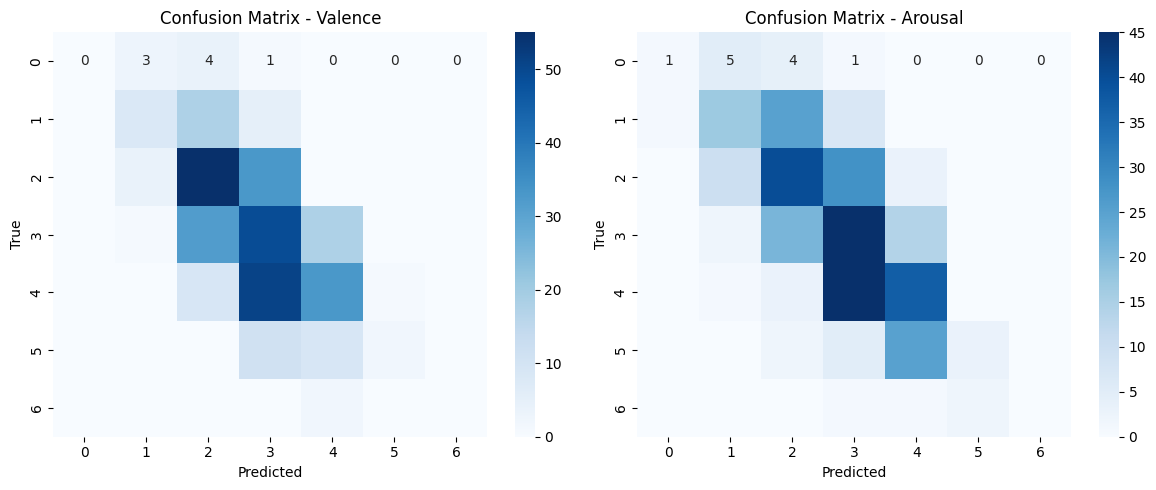

In [22]:
# Plot confusion matrix for valence and arousal separately
cm_valence = confusion_matrix(y_test_rounded[:, 0], y_pred_rounded[:, 0])
cm_arousal = confusion_matrix(y_test_rounded[:, 1], y_pred_rounded[:, 1])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm_valence, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Valence')

plt.subplot(1, 2, 2)
sns.heatmap(cm_arousal, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Arousal')

plt.tight_layout()
plt.show()

In [23]:
model.save("densenet121_mer_model.keras")